# Ridge Regression with Holdout: Gas Mileage Prediction

In [1]:
# imports
import numpy as np
import pandas as pd
#import piplite
#await piplite.install('seaborn')
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge # for Ridge Regression
from sklearn.pipeline import make_pipeline # for creating ML pipelines
from sklearn.preprocessing import StandardScaler # for feature scaling and standardization
from sklearn.model_selection import train_test_split # for splitting datasets into two or three subsets

In [2]:
# Reference: https://archive.ics.uci.edu/ml/datasets/Auto+MPG
df = pd.read_csv("auto_mpg.csv")
display(df)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [4]:
df.drop(df.columns[[1, 6, 7, 8]], axis=1, inplace=True)    # Discard the discrete-valued feature columns (cylinders, model_year, origin, car_name)
df.dropna(axis=0, inplace=True)                            # Discard rows with missing values and save the new DataFrame on the same DataFrame
display(df)

,mpg,displacement,horsepower,weight,acceleration
0,18.0,307.0,130.0,3504,12.0
1,15.0,350.0,165.0,3693,11.5
2,18.0,318.0,150.0,3436,11.0
3,16.0,304.0,150.0,3433,12.0
4,17.0,302.0,140.0,3449,10.5
...,...,...,...,...,...
393,27.0,140.0,86.0,2790,15.6
394,44.0,97.0,52.0,2130,24.6
395,32.0,135.0,84.0,2295,11.6
396,28.0,120.0,79.0,2625,18.6


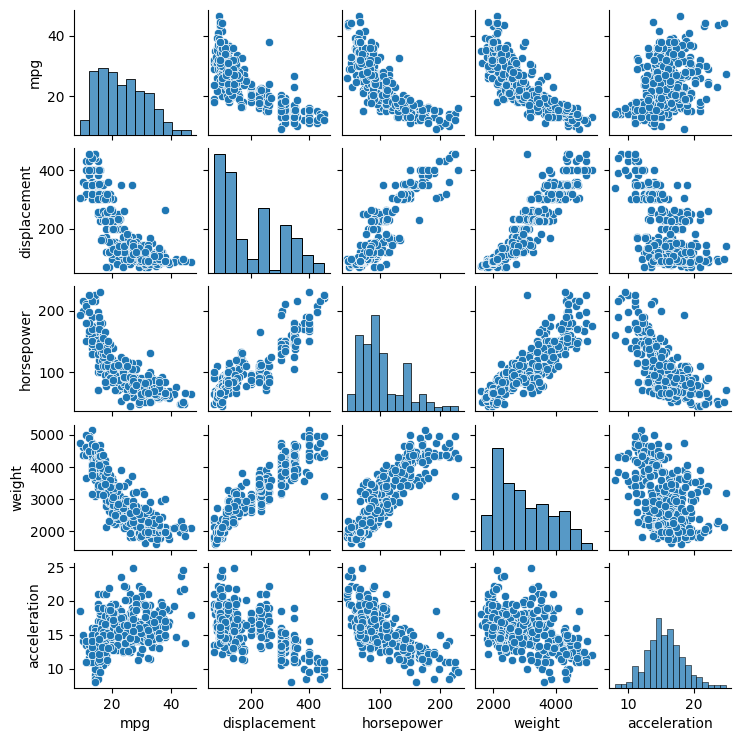

In [5]:
# creating pairplot to see relationship of numerical features to one another
sns.pairplot(df, height=1.5)
plt.show()

Split the data into 70% training, 15% validation, and 15% testing

In [6]:
# extracting the regressors and the target from the DataFrame
X = df.iloc[:, 1:].to_numpy() # displacement, horsepower, weight, acceleration
y = df.iloc[:, 0].to_numpy() # mpg

# creating the validation and test data
X_train, X_2, y_train, y_2 = train_test_split(X, y, test_size=0.3, random_state=0) # split data into 70% training data, 30% validation + test data
X_val, X_test, y_val, y_test = train_test_split(X_2, y_2, test_size=0.5, random_state=0) # split the 30% validation + test data into 15% validation data and 15% test data

# checking the shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print()
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (274, 4)
X_val shape: (59, 4)
X_test shape: (59, 4)

y_train shape: (274,)
y_val shape: (59,)
y_test shape: (59,)


In [7]:
# searching over different regularization parameter values
max_R2 = 0
best_alpha = 0
best_mdl = 0

# searching for the best linear regression model by varying the L2 parameter
for alpha in np.array([0, 0.1, 0.5, 1, 5, 10, 50, 100]):
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(X_train, y_train)
    print(f"Alpha: {alpha}")
    train_R2 = mdl.score(X_train, y_train) # getting R-squared for training data
    val_R2 = mdl.score(X_val, y_val) # getting R-squared for validation data
    print(f"\tCoefficients: {mdl[1].coef_}")
    print(f"\tIntercept: {mdl[1].intercept_}")
    print(f"\tTraining accuracy (R2): {train_R2}")
    print(f"\tValidation accuracy (R2): {val_R2}")
    if val_R2 > max_R2:
        max_R2 = val_R2
        best_alpha = alpha
        best_mdl = mdl

Alpha: 0.0
	Coefficients: [-1.13119186 -1.18514945 -4.45320355 -0.02143731]
	Intercept: 23.16897810218978
	Training accuracy (R2): 0.7163772295250078
	Validation accuracy (R2): 0.7311232674499168
Alpha: 0.1
	Coefficients: [-1.13920777 -1.1888433  -4.44187774 -0.02378093]
	Intercept: 23.16897810218978
	Training accuracy (R2): 0.7163770067949723
	Validation accuracy (R2): 0.7311449733206559
Alpha: 0.5
	Coefficients: [-1.17020165 -1.20315672 -4.39789812 -0.0327753 ]
	Intercept: 23.16897810218978
	Training accuracy (R2): 0.7163719069815744
	Validation accuracy (R2): 0.7312265445875918
Alpha: 1.0
	Coefficients: [-1.20668383 -1.22007015 -4.34572296 -0.04321534]
	Intercept: 23.16897810218978
	Training accuracy (R2): 0.7163570699068773
	Validation accuracy (R2): 0.7313177469668661
Alpha: 5.0
	Coefficients: [-1.42988502 -1.32535156 -4.01375903 -0.1023958 ]
	Intercept: 23.16897810218978
	Training accuracy (R2): 0.7160307781509576
	Validation accuracy (R2): 0.7317586233307869
Alpha: 10.0
	Coeffic

In [8]:
# printing the results of the best model
print(f"Best alpha: {best_alpha}")
print(f"Coefficients: {best_mdl[1].coef_}")
print(f"Intercept: {best_mdl[1].intercept_}")

Best alpha: 10.0
Coefficients: [-1.60167334 -1.40918408 -3.73352704 -0.13865552]
Intercept: 23.16897810218978


Evaluate the best model on test data

Testing accuracy (R2) of Best Model: 0.6235892166451613


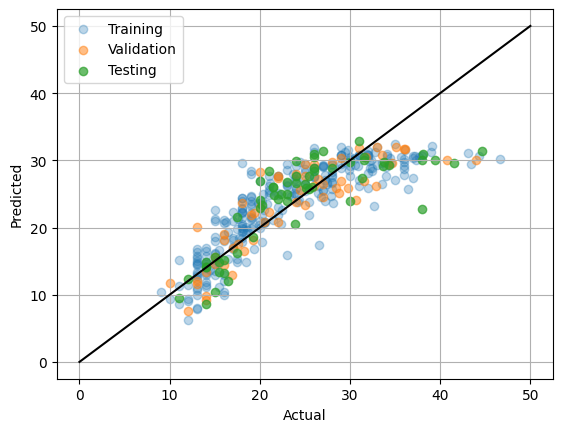

In [9]:
# evaluating the best model on test data
test_R2 = best_mdl.score(X_test,y_test)
print(f"Testing accuracy (R2) of Best Model: {test_R2}")
y_train_pred = best_mdl.predict(X_train)
y_val_pred = best_mdl.predict(X_val)
y_test_pred = best_mdl.predict(X_test)

# plotting the actual vs. predicted values
plt.plot(np.array([0, 50]), np.array([0, 50]), color='k', label='_nolegend_') # creating 45-degree line
plt.scatter(y_train, y_train_pred, alpha=0.3, label="Training") # plotting actual training target vs. predicted training target
plt.scatter(y_val, y_val_pred, alpha=0.5, label="Validation") # plotting actual validation target vs. predicted validation target
plt.scatter(y_test, y_test_pred, alpha=0.7, label="Testing") # plotting actual test target vs. predicted test target
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid()
plt.show()